# SBI for ClonalOrigin sequential model and `SimBac` simulation

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import Phylo
import torch
from sbi.inference import NPE_C
from sbi.analysis import plot_summary
import sys
sys.path.append('../pysimARG')
from clonal_genealogy import ClonalTree
from newick_to_tree import newick_to_tree
from localtree_simbac import load_local_trees
from homoplasy_index_simbac import homoplasy_index_simbac
from ClonalOrigin_seq_sim import ClonalOrigin_seq_sim
from G4_test import G4_test
from LD_r import LD_r

torch_device = "cpu"

## Load simulation data

In [2]:
genome_simbac = np.loadtxt("../data/SimBac/genomes_bool.csv", delimiter=",", dtype=bool)

In [3]:
genome_simbac.shape

(10, 100000)

In [4]:
phylo_tree = Phylo.read("../data/SimBac/clonal_frame.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

                                                                   _______ 2
                                        __________________________|
                            ___________|                          |_______ 8
                           |           |
                           |           |___________________________________ 1
                           |
                        ___|                         _____________________ 6
                       |   |                       ,|
                       |   |                       ||  ___________________ 3
                       |   |                       ||_|
                       |   |_______________________|  |___________________ 9
  _____________________|                           |
 |                     |                           |         _____________ 5
 |                     |                           |________|
_|                     |                                    |_____________ 7
 |                  

In [5]:
file_path = "../data/SimBac/local_tree.nwk"

blocks = load_local_trees(file_path)

print(f"\nSuccessfully loaded {len(blocks)} local trees.")

print("\n--- Genome Map Overview ---")
current_position = 1

for i, (span, local_tree) in enumerate(blocks[:5]):
    end_position = current_position + span - 1
    print(f"Block {i+1}: Sites {current_position:05d} to {end_position:05d} (Length: {span}bp)")
    current_position += span

Parsing local trees...

Successfully loaded 10618 local trees.

--- Genome Map Overview ---
Block 1: Sites 00001 to 00025 (Length: 25bp)
Block 2: Sites 00026 to 00060 (Length: 35bp)
Block 3: Sites 00061 to 00088 (Length: 28bp)
Block 4: Sites 00089 to 00119 (Length: 31bp)
Block 5: Sites 00120 to 00123 (Length: 4bp)


## Get summary statistics from SimBac data

In [6]:
x_o_500 = np.full(7, np.nan)
x_o_2000 = np.full(7, np.nan)
x_o_6000 = np.full(7, np.nan)

x_o_500[6] = 500
x_o_2000[6] = 2000
x_o_6000[6] = 6000

x_o_500, x_o_2000, x_o_6000

(array([ nan,  nan,  nan,  nan,  nan,  nan, 500.]),
 array([  nan,   nan,   nan,   nan,   nan,   nan, 2000.]),
 array([  nan,   nan,   nan,   nan,   nan,   nan, 6000.]))

### Randomly choose a segment of length 500 bp

In [7]:
np.random.seed(100)
L = 500
start_pos = np.random.randint(1, genome_simbac.shape[1]-L+1)
print(f"Starting position is {start_pos}.")
mat = genome_simbac[:, start_pos-1:start_pos+L-1]

has_true = mat.any(axis=0)
has_false = ~mat.all(axis=0)
idx_seg = np.where(has_true & has_false)[0]

ld_near, ld_far, g4_near, g4_far = 0, 0, 0, 0
if idx_seg.size >= 2:
    for i in range(idx_seg.size - 1):
        for j in range(i + 1, idx_seg.size):
            dist_ij = idx_seg[j] - idx_seg[i]
            idx_pair = [idx_seg[i], idx_seg[j]]
            if dist_ij < L/2:
                ld_near += LD_r(mat[:, idx_pair])
                g4_near += G4_test(mat[:, idx_pair])
            else:
                ld_far += LD_r(mat[:, idx_pair])
                g4_far += G4_test(mat[:, idx_pair])
    
    s_far = (int(L/2) + 1) * (int(L/2)) / 2
    s_near = L * (L - 1) / 2 - s_far
    x_o_500[0] = ld_near / s_near
    x_o_500[1] = ld_far / s_far
    x_o_500[2] = g4_near / s_near
    x_o_500[3] = g4_far / s_far
else:
    x_o_500[:4] = 0

x_o_500[4] = homoplasy_index_simbac(blocks, genome_simbac, start_pos, L)
count_S = idx_seg.size
x_o_500[5] = count_S / L

x_o_500

Starting position is 38409.


array([2.12980173e-03, 1.66728532e-03, 1.76706827e-03, 1.56175299e-03,
       5.17241379e-02, 1.10000000e-01, 5.00000000e+02])

### Randomly choose a segment of length 2000 bp

In [8]:
L = 2000
start_pos = np.random.randint(1, genome_simbac.shape[1]-L+1)
print(f"Starting position is {start_pos}.")
mat = genome_simbac[:, start_pos-1:start_pos+L-1]

has_true = mat.any(axis=0)
has_false = ~mat.all(axis=0)
idx_seg = np.where(has_true & has_false)[0]

ld_near, ld_far, g4_near, g4_far = 0, 0, 0, 0
if idx_seg.size >= 2:
    for i in range(idx_seg.size - 1):
        for j in range(i + 1, idx_seg.size):
            dist_ij = idx_seg[j] - idx_seg[i]
            idx_pair = [idx_seg[i], idx_seg[j]]
            if dist_ij < L/2:
                ld_near += LD_r(mat[:, idx_pair])
                g4_near += G4_test(mat[:, idx_pair])
            else:
                ld_far += LD_r(mat[:, idx_pair])
                g4_far += G4_test(mat[:, idx_pair])
    
    s_far = (int(L/2) + 1) * (int(L/2)) / 2
    s_near = L * (L - 1) / 2 - s_far
    x_o_2000[0] = ld_near / s_near
    x_o_2000[1] = ld_far / s_far
    x_o_2000[2] = g4_near / s_near
    x_o_2000[3] = g4_far / s_far
else:
    x_o_2000[:4] = 0

x_o_2000[4] = homoplasy_index_simbac(blocks, genome_simbac, start_pos, L)
count_S = idx_seg.size
x_o_2000[5] = count_S / L

x_o_2000

Starting position is 56089.


array([1.20078541e-03, 1.28784540e-03, 7.05372039e-04, 9.47052947e-04,
       2.45098039e-02, 9.95000000e-02, 2.00000000e+03])

### Randomly choose a segment of length 6000 bp

In [13]:
L = 6000
start_pos = np.random.randint(1, genome_simbac.shape[1]-L+1)
print(f"Starting position is {start_pos}.")
mat = genome_simbac[:, start_pos-1:start_pos+L-1]

has_true = mat.any(axis=0)
has_false = ~mat.all(axis=0)
idx_seg = np.where(has_true & has_false)[0]

ld_near, ld_far, g4_near, g4_far = 0, 0, 0, 0
if idx_seg.size >= 2:
    for i in range(idx_seg.size - 1):
        for j in range(i + 1, idx_seg.size):
            dist_ij = idx_seg[j] - idx_seg[i]
            idx_pair = [idx_seg[i], idx_seg[j]]
            if dist_ij < L/2:
                ld_near += LD_r(mat[:, idx_pair])
                g4_near += G4_test(mat[:, idx_pair])
            else:
                ld_far += LD_r(mat[:, idx_pair])
                g4_far += G4_test(mat[:, idx_pair])
    
    s_far = (int(L/2) + 1) * (int(L/2)) / 2
    s_near = L * (L - 1) / 2 - s_far
    x_o_6000[0] = ld_near / s_near
    x_o_6000[1] = ld_far / s_far
    x_o_6000[2] = g4_near / s_near
    x_o_6000[3] = g4_far / s_far
else:
    x_o_6000[:4] = 0

x_o_6000[4] = homoplasy_index_simbac(blocks, genome_simbac, start_pos, L)
count_S = idx_seg.size
x_o_6000[5] = count_S / L

x_o_6000

Starting position is 79684.


array([1.95249691e-03, 1.65602094e-03, 1.70160424e-03, 2.25635899e-03,
       1.61943320e-02, 1.21500000e-01, 6.00000000e+03])

In [17]:
x_o_500_numpy = x_o_500.copy()
x_o_2000_numpy = x_o_2000.copy()
x_o_6000_numpy = x_o_6000.copy()

x_o_500_numpy, x_o_2000_numpy, x_o_6000_numpy

(array([2.12980173e-03, 1.66728532e-03, 1.76706827e-03, 1.56175299e-03,
        5.17241379e-02, 1.10000000e-01, 5.00000000e+02]),
 array([1.20078541e-03, 1.28784540e-03, 7.05372039e-04, 9.47052947e-04,
        2.45098039e-02, 9.95000000e-02, 2.00000000e+03]),
 array([1.95249691e-03, 1.65602094e-03, 1.70160424e-03, 2.25635899e-03,
        1.61943320e-02, 1.21500000e-01, 6.00000000e+03]))

In [18]:
x_o_500 = torch.tensor(x_o_500, device=torch_device)
x_o_500 = x_o_500.to(torch.float32)

x_o_2000 = torch.tensor(x_o_2000, device=torch_device)
x_o_2000 = x_o_2000.to(torch.float32)

x_o_6000 = torch.tensor(x_o_6000, device=torch_device)
x_o_6000 = x_o_6000.to(torch.float32)

In [19]:
x_o_2000.dtype, x_o_500.dtype, x_o_6000.dtype

(torch.float32, torch.float32, torch.float32)

### Load simulations from ClonalOrigin model

In [14]:
theta1 = np.loadtxt('../data/theta1.csv', delimiter=",")
x1 = np.loadtxt('../data/x1.csv', delimiter=",")

print(theta1.shape, x1.shape)

(5000, 4) (5000, 7)


In [15]:
theta2 = np.loadtxt('../data/theta2.csv', delimiter=",")
x2 = np.loadtxt('../data/x2.csv', delimiter=",")

print(theta2.shape, x2.shape)

(5000, 4) (5000, 7)


In [16]:
x = np.vstack([x1, x2])
theta = np.vstack([theta1, theta2])

print(theta.shape, x.shape)

(10000, 4) (10000, 7)


In [20]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()
theta

tensor([[5.1383e-03, 3.0915e+02, 7.1336e-03, 1.3250e+03],
        [1.2469e-02, 1.9178e+02, 4.8865e-02, 1.2380e+03],
        [4.4089e-02, 5.3824e+01, 1.3262e-02, 2.8730e+03],
        ...,
        [5.9294e-02, 1.9140e+02, 1.7278e-01, 3.9520e+03],
        [8.5187e-02, 2.6280e+02, 7.1654e-02, 8.0960e+03],
        [4.8094e-03, 4.9657e+02, 1.4620e-01, 2.5760e+03]])

In [21]:
x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()
x

tensor([[8.9901e-05, 1.1623e-04, 1.5205e-06,  ..., 0.0000e+00, 2.5660e-02,
         1.3250e+03],
        [1.7098e-03, 1.5493e-03, 2.5792e-04,  ..., 3.7313e-02, 1.0420e-01,
         1.2380e+03],
        [1.6484e-04, 2.0595e-04, 7.4341e-05,  ..., 1.0000e-02, 3.4459e-02,
         2.8730e+03],
        ...,
        [1.9793e-02, 1.9223e-02, 2.7178e-02,  ..., 1.5781e-01, 4.0106e-01,
         3.9520e+03],
        [8.7358e-03, 7.9509e-03, 1.5197e-02,  ..., 7.7819e-02, 2.7372e-01,
         8.0960e+03],
        [2.2978e-02, 1.9046e-02, 1.4800e-02,  ..., 1.3135e-01, 3.8509e-01,
         2.5760e+03]])

In [22]:
theta.dtype, x.dtype

(torch.float32, torch.float32)

## Fit NPE

In [23]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference = NPE_C(density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [24]:
density_estimator = inference.append_simulations(theta, x).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 135 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-05-08T10_15_52.846069' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


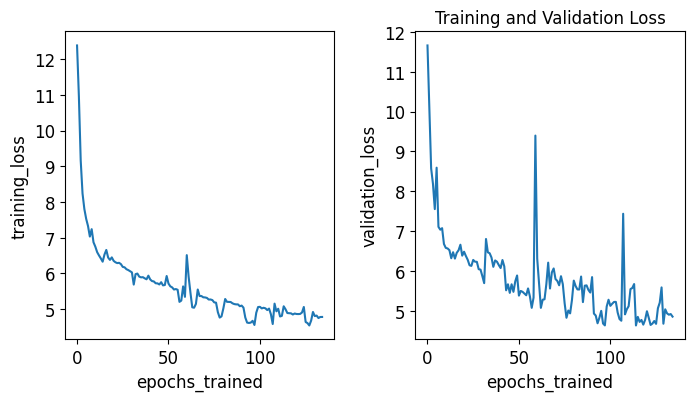

In [25]:
fig, axes = plot_summary(
    inference, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

## Posterior distributions for different sequence length

In [28]:
theta_trained_2000 = posterior.set_default_x(x_o_2000).sample((num_posterior_samples,), x=x_o_2000)
theta_trained_2000_numpy = theta_trained_2000.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 37524.86it/s]


In [29]:
theta_trained_500 = posterior.set_default_x(x_o_500).sample((num_posterior_samples,), x=x_o_500)
theta_trained_500_numpy = theta_trained_500.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 28459.50it/s]


In [30]:
theta_trained_6000 = posterior.set_default_x(x_o_6000).sample((num_posterior_samples,), x=x_o_6000)
theta_trained_6000_numpy = theta_trained_6000.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 37497.02it/s]


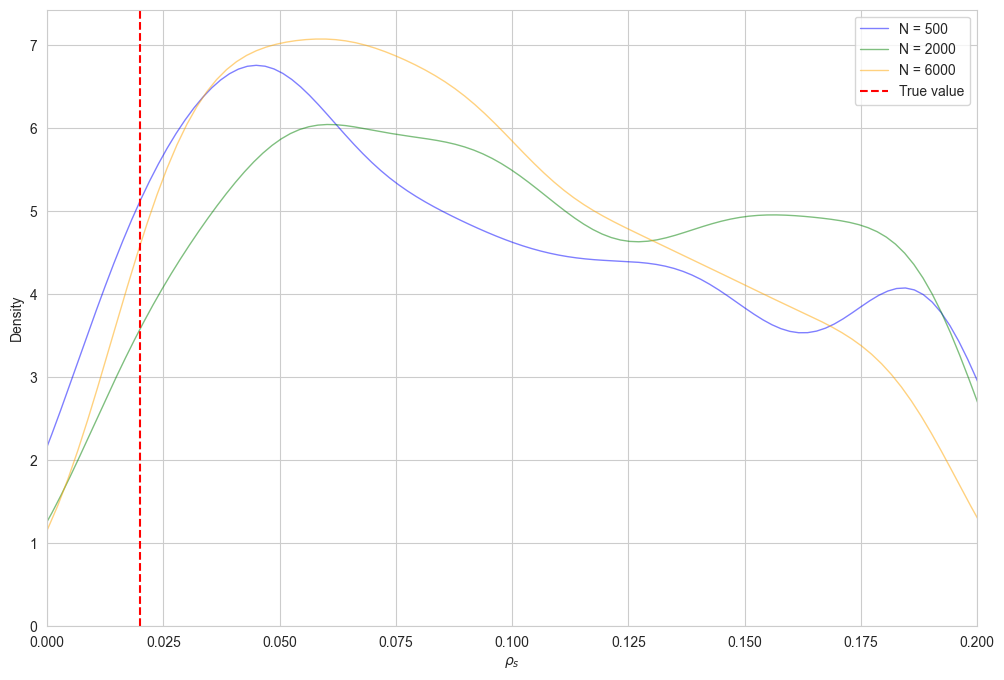

In [31]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 0], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 0], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 0], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.2)
plt.legend()
plt.show()

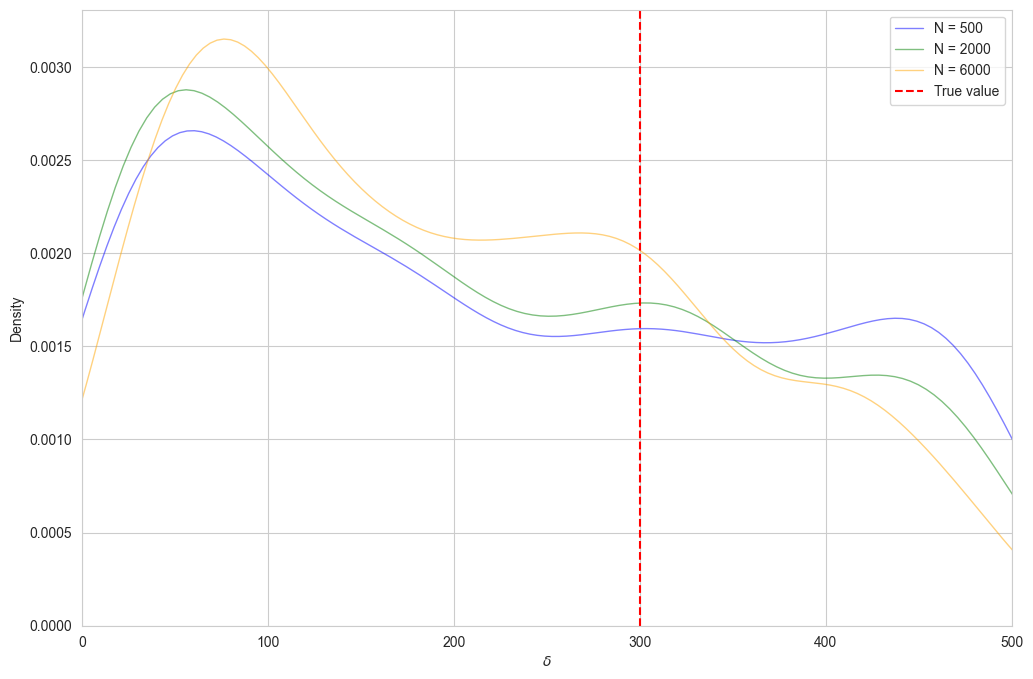

In [32]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 1], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 1], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 1], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=300, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\delta$')
plt.xlim(0.0, 500.0)
plt.legend()
plt.show()

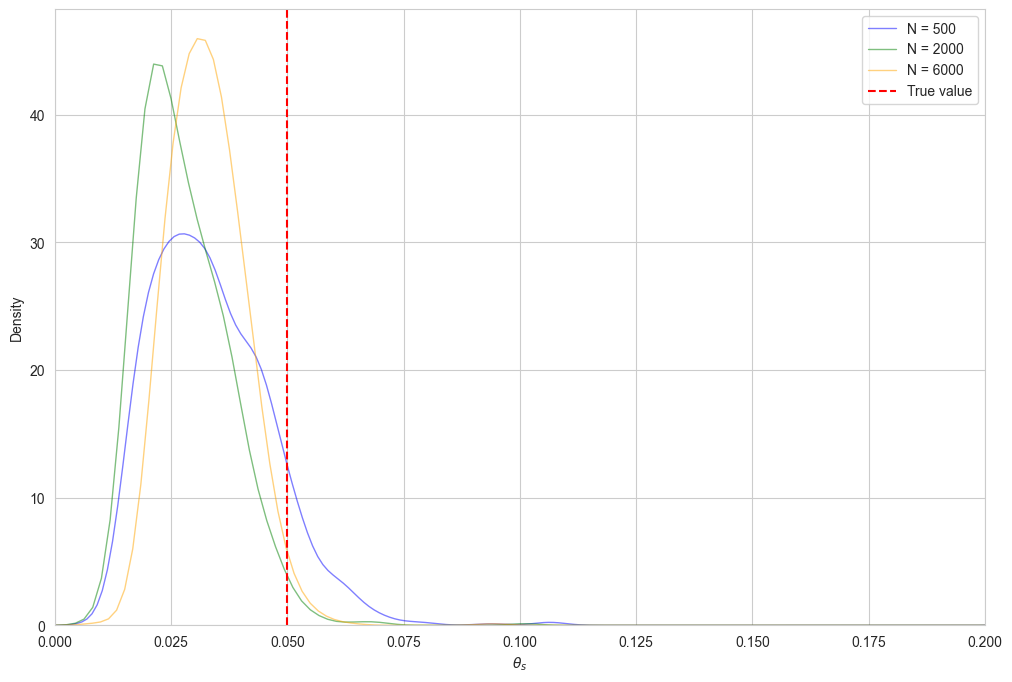

In [33]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 2], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 2], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 2], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=0.05, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\theta_s$')
plt.xlim(0.0, 0.2)
plt.legend()
plt.show()

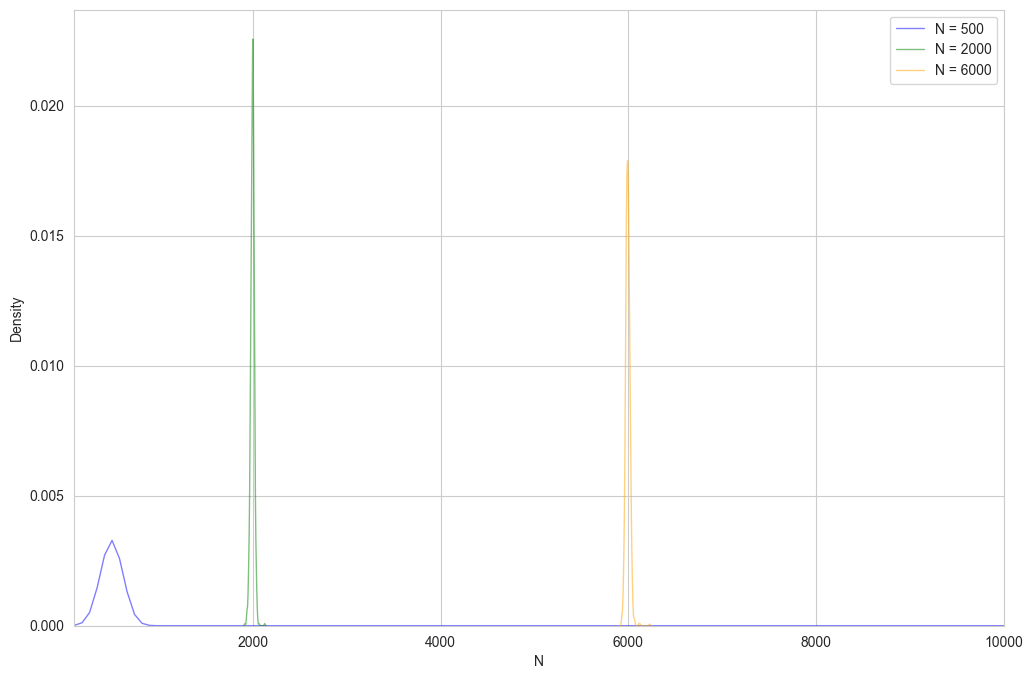

In [34]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 3], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 3], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 3], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

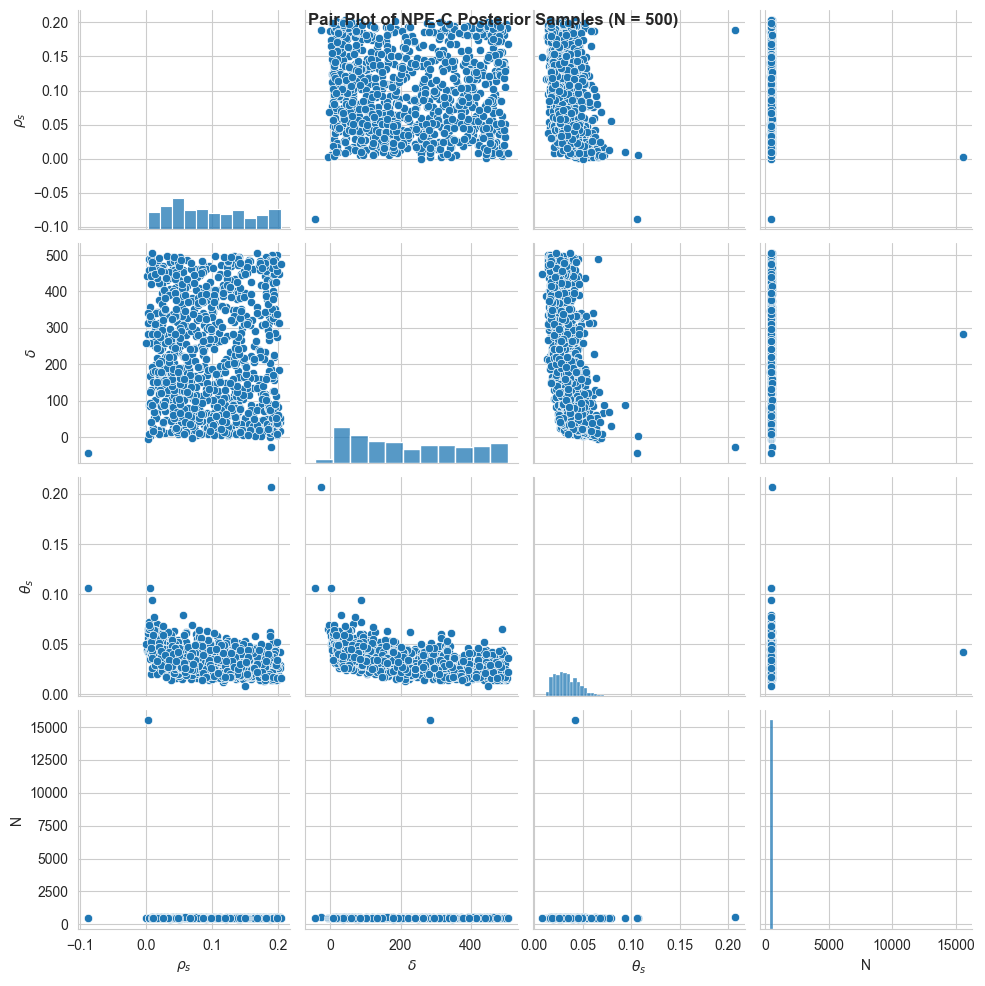

In [35]:
df_500 = pd.DataFrame(theta_trained_500_numpy, columns=[r"$\rho_s$", r"$\delta$", r"$\theta_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

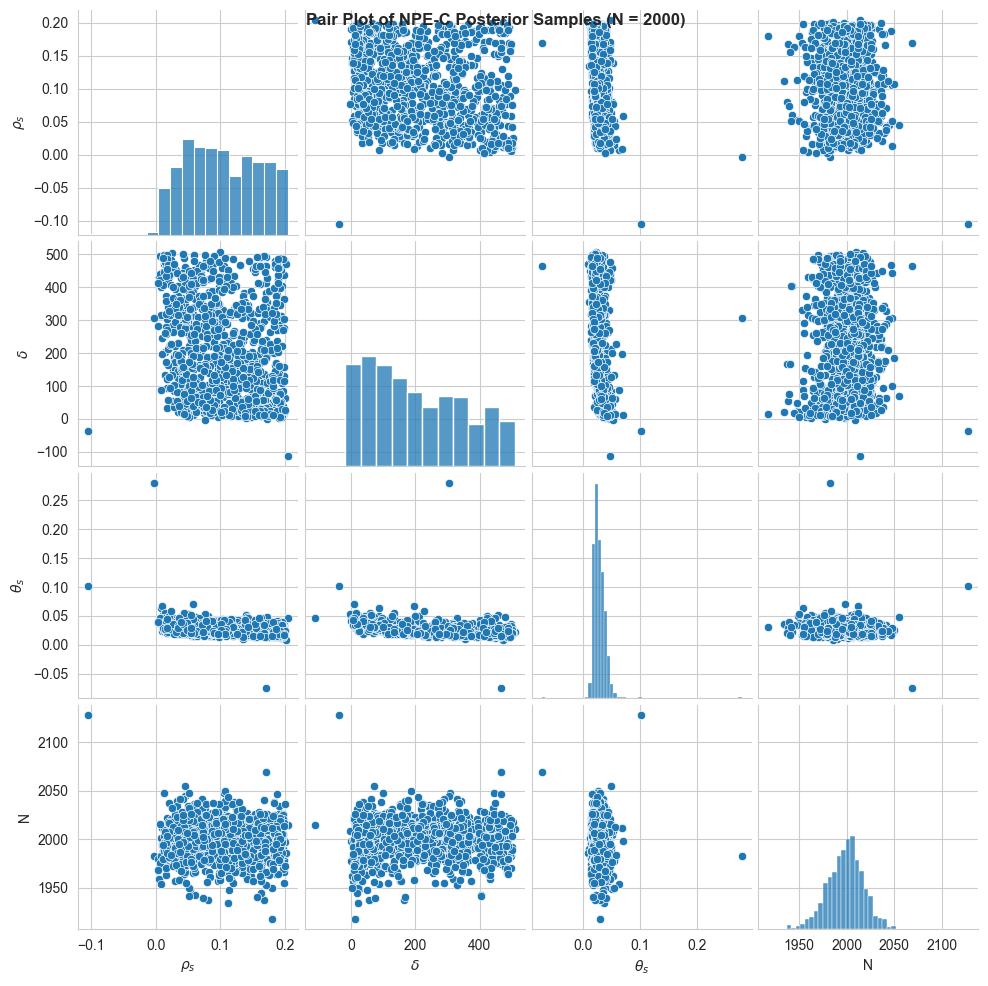

In [36]:
df_2000 = pd.DataFrame(theta_trained_2000_numpy, columns=[r"$\rho_s$", r"$\delta$", r"$\theta_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

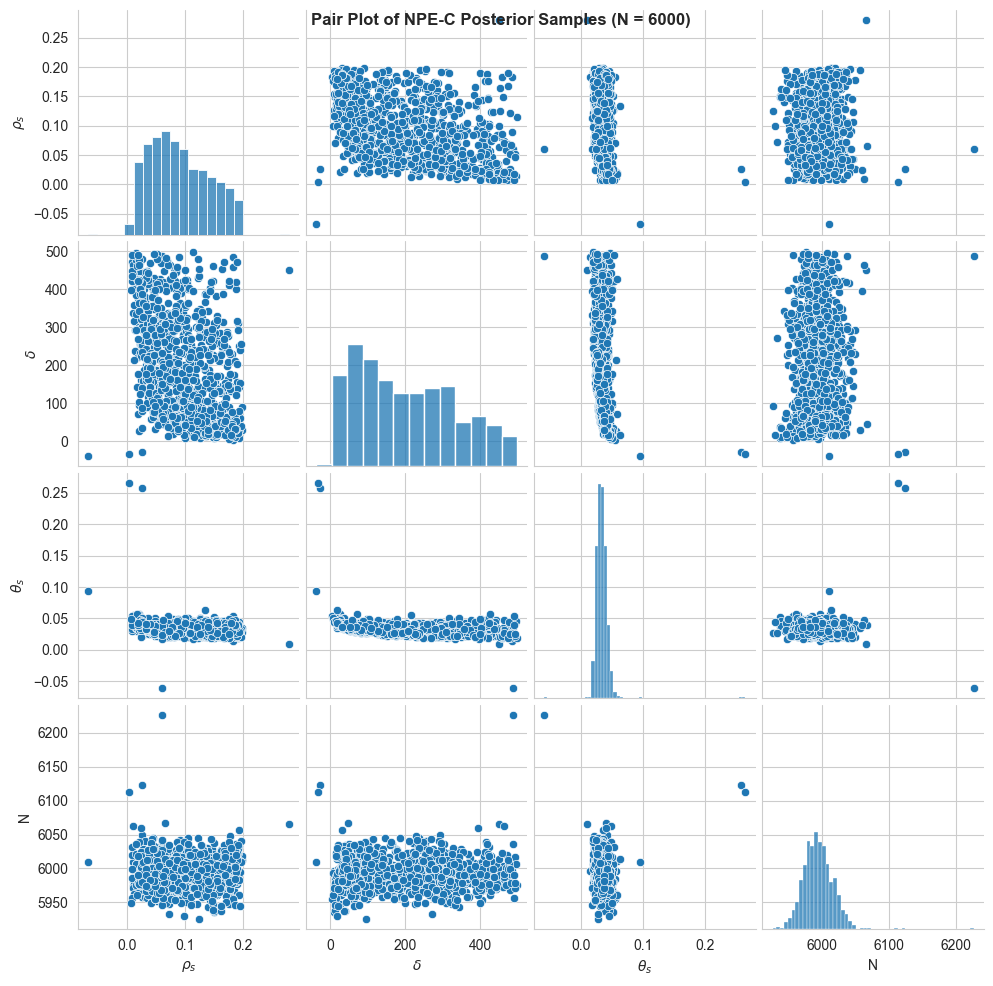

In [37]:
df_6000 = pd.DataFrame(theta_trained_6000_numpy, columns=[r"$\rho_s$", r"$\delta$", r"$\theta_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

## ClonalOrigin observations?

In [41]:
clonal_tree = ClonalTree(n=10)

edge, node_height = newick_to_tree(phylo_tree)
clonal_tree.edge = edge
clonal_tree.node_height = node_height
clonal_tree.height = np.max(node_height)
clonal_tree.length = np.sum(edge[:, 2])

rho_site = 0.02
theta_site = 0.05
delta = 300

In [42]:
np.random.seed(100)
CO_x_500 = ClonalOrigin_seq_sim(clonal_tree, rho_site, theta_site, 500, delta)
CO_x_2000 = ClonalOrigin_seq_sim(clonal_tree, rho_site, theta_site, 2000, delta)
CO_x_6000 = ClonalOrigin_seq_sim(clonal_tree, rho_site, theta_site, 6000, delta)

CO_x_500, CO_x_2000, CO_x_6000

(array([1.06672436e-03, 4.51574654e-04, 2.03480589e-04, 6.37450199e-05,
        5.26315789e-02, 7.20000000e-02, 5.00000000e+02]),
 array([4.09136201e-03, 2.29929581e-03, 3.52419086e-03, 4.97102897e-03,
        5.88235294e-02, 1.60000000e-01, 2.00000000e+03]),
 array([3.47179237e-03, 2.52398260e-03, 2.53054722e-03, 3.38576030e-03,
        4.17940877e-02, 1.56666667e-01, 6.00000000e+03]))

In [44]:
CO_x_500_numpy = CO_x_500.copy()
CO_x_2000_numpy = CO_x_2000.copy()
CO_x_6000_numpy = CO_x_6000.copy()

In [45]:
CO_x_500 = torch.tensor(CO_x_500, device=torch_device)
CO_x_500 = CO_x_500.to(torch.float32)

CO_x_2000 = torch.tensor(CO_x_2000, device=torch_device)
CO_x_2000 = CO_x_2000.to(torch.float32)

CO_x_6000 = torch.tensor(CO_x_6000, device=torch_device)
CO_x_6000 = CO_x_6000.to(torch.float32)

In [46]:
CO_x_500.dtype, CO_x_2000.dtype, CO_x_6000.dtype

(torch.float32, torch.float32, torch.float32)

In [47]:
theta_trained_2000 = posterior.set_default_x(CO_x_2000).sample((num_posterior_samples,), x=CO_x_2000)
theta_trained_2000_numpy = theta_trained_2000.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 37920.78it/s]


In [48]:
theta_trained_500 = posterior.set_default_x(CO_x_500).sample((num_posterior_samples,), x=CO_x_500)
theta_trained_500_numpy = theta_trained_500.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 23512.12it/s]


In [49]:
theta_trained_6000 = posterior.set_default_x(CO_x_6000).sample((num_posterior_samples,), x=CO_x_6000)
theta_trained_6000_numpy = theta_trained_6000.cpu().numpy()

100%|██████████| 1000/1000 [00:00<00:00, 22467.40it/s]


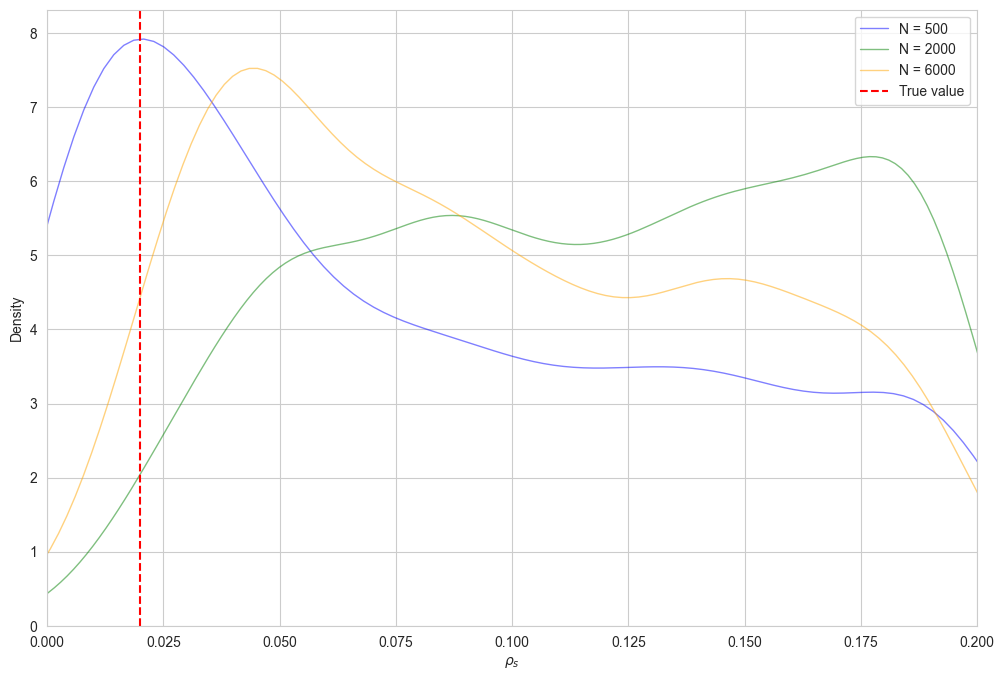

In [51]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 0], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 0], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 0], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.2)
plt.legend()
plt.show()

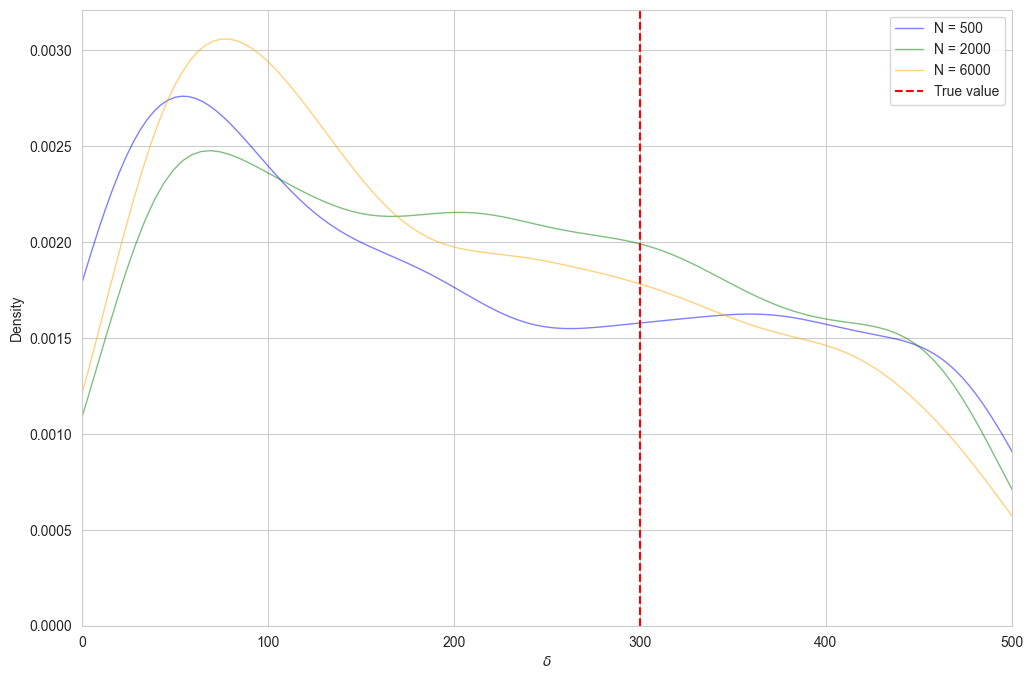

In [52]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 1], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 1], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 1], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=300, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\delta$')
plt.xlim(0.0, 500.0)
plt.legend()
plt.show()

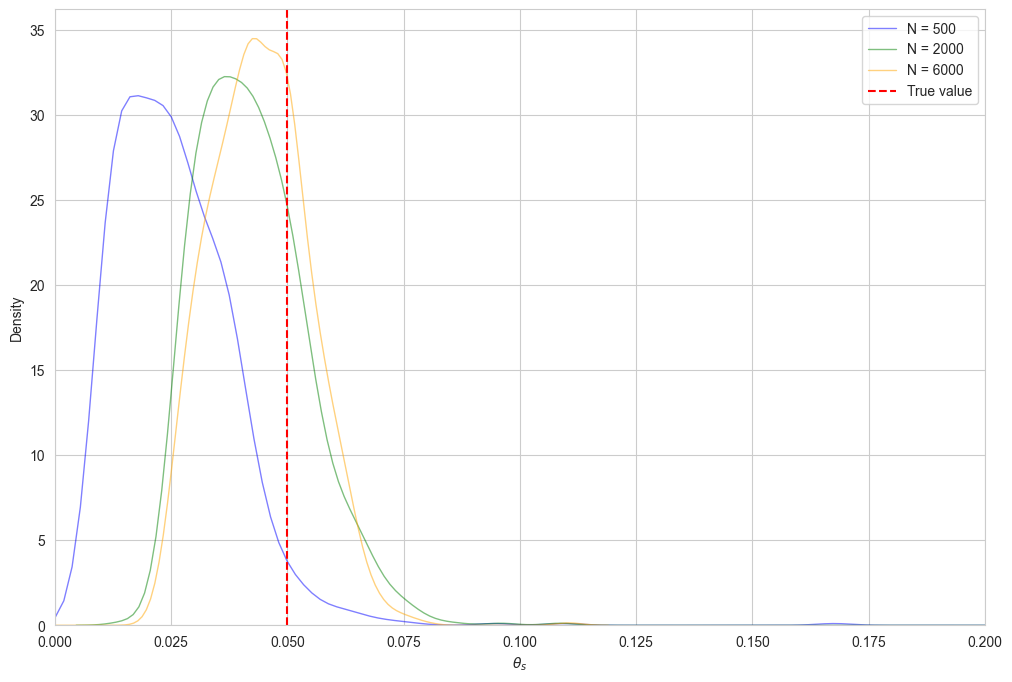

In [53]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 2], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 2], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 2], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.axvline(x=0.05, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\theta_s$')
plt.xlim(0.0, 0.2)
plt.legend()
plt.show()

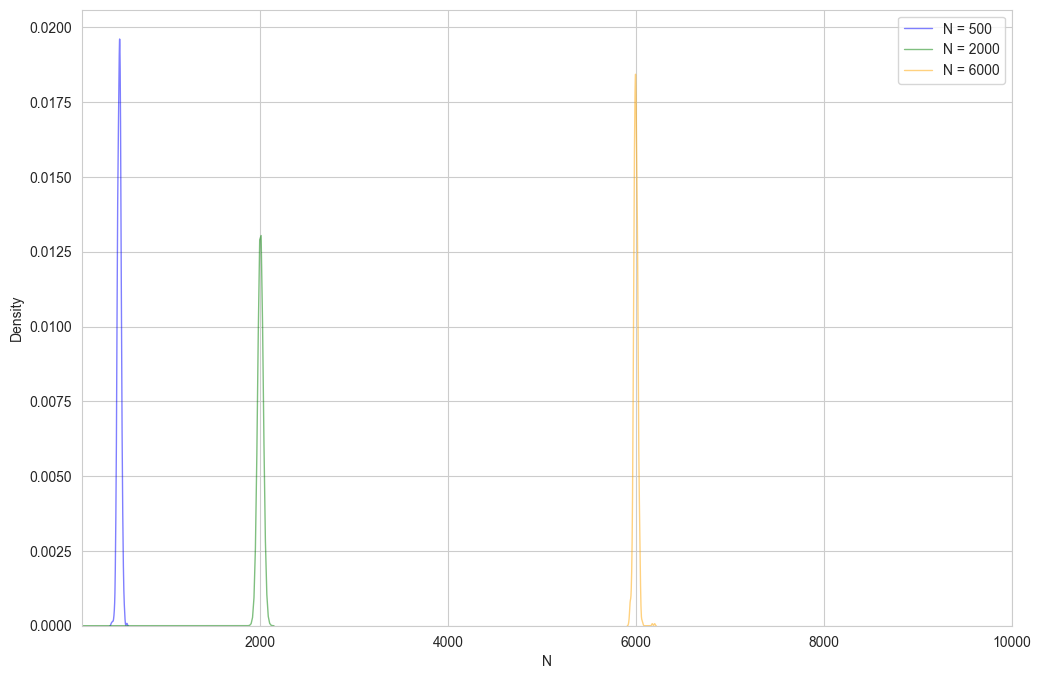

In [54]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta_trained_500_numpy[:, 3], label='N = 500', color='blue', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_2000_numpy[:, 3], label='N = 2000', color='green', linewidth=1, alpha=0.5)
sns.kdeplot(theta_trained_6000_numpy[:, 3], label='N = 6000', color='orange', linewidth=1, alpha=0.5)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

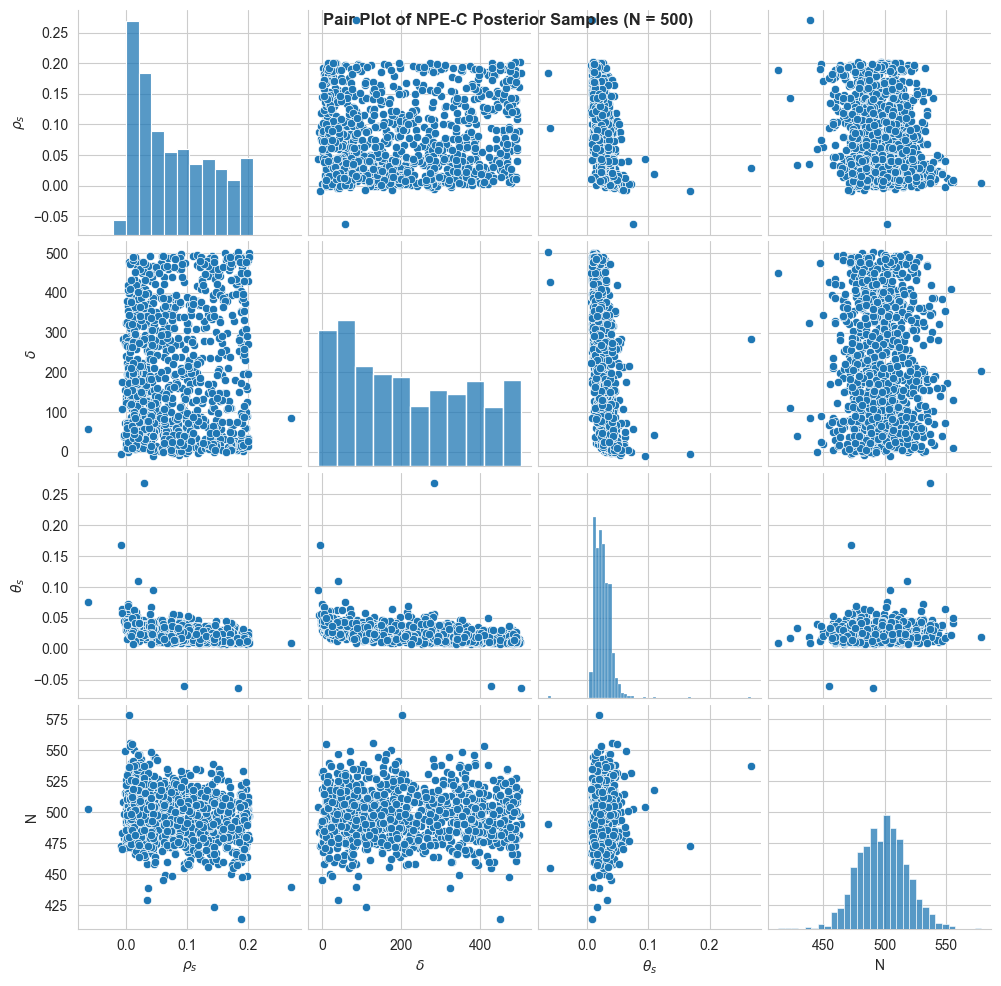

In [55]:
df_500 = pd.DataFrame(theta_trained_500_numpy, columns=[r"$\rho_s$", r"$\delta$", r"$\theta_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

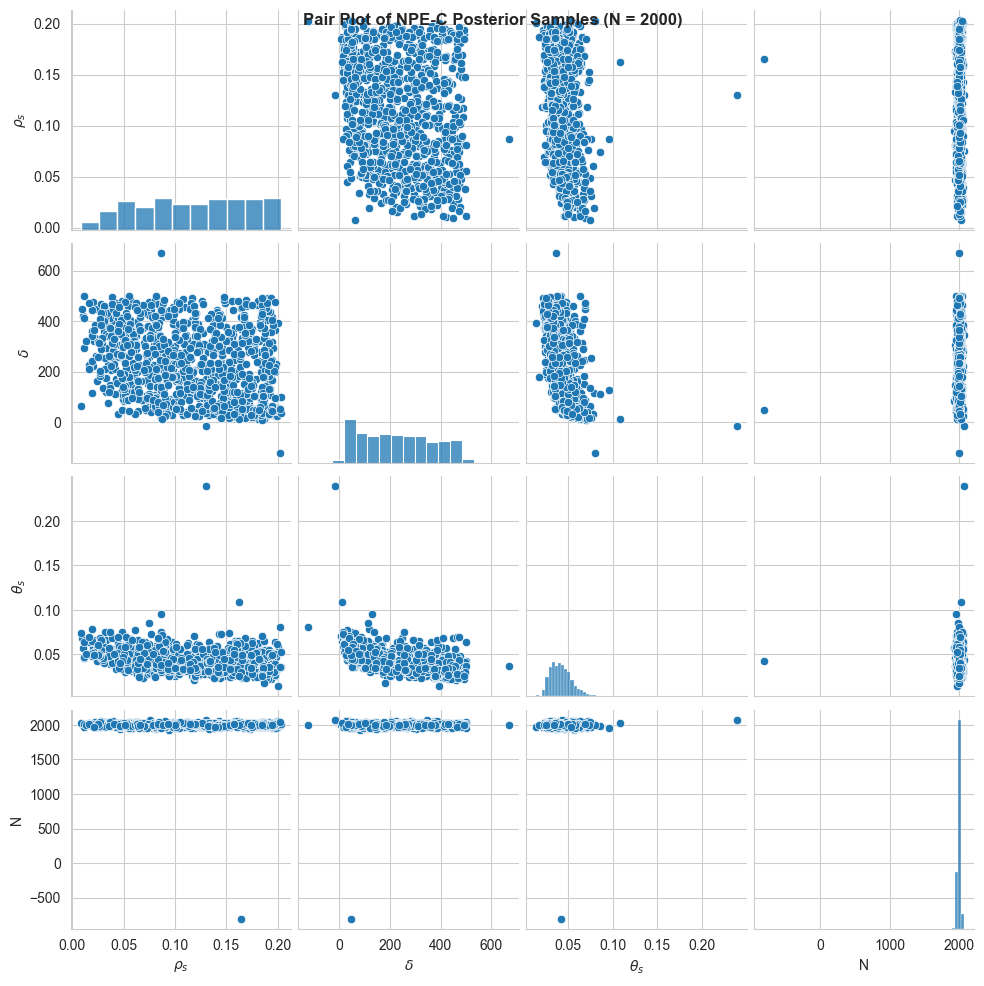

In [56]:
df_2000 = pd.DataFrame(theta_trained_2000_numpy, columns=[r"$\rho_s$", r"$\delta$", r"$\theta_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

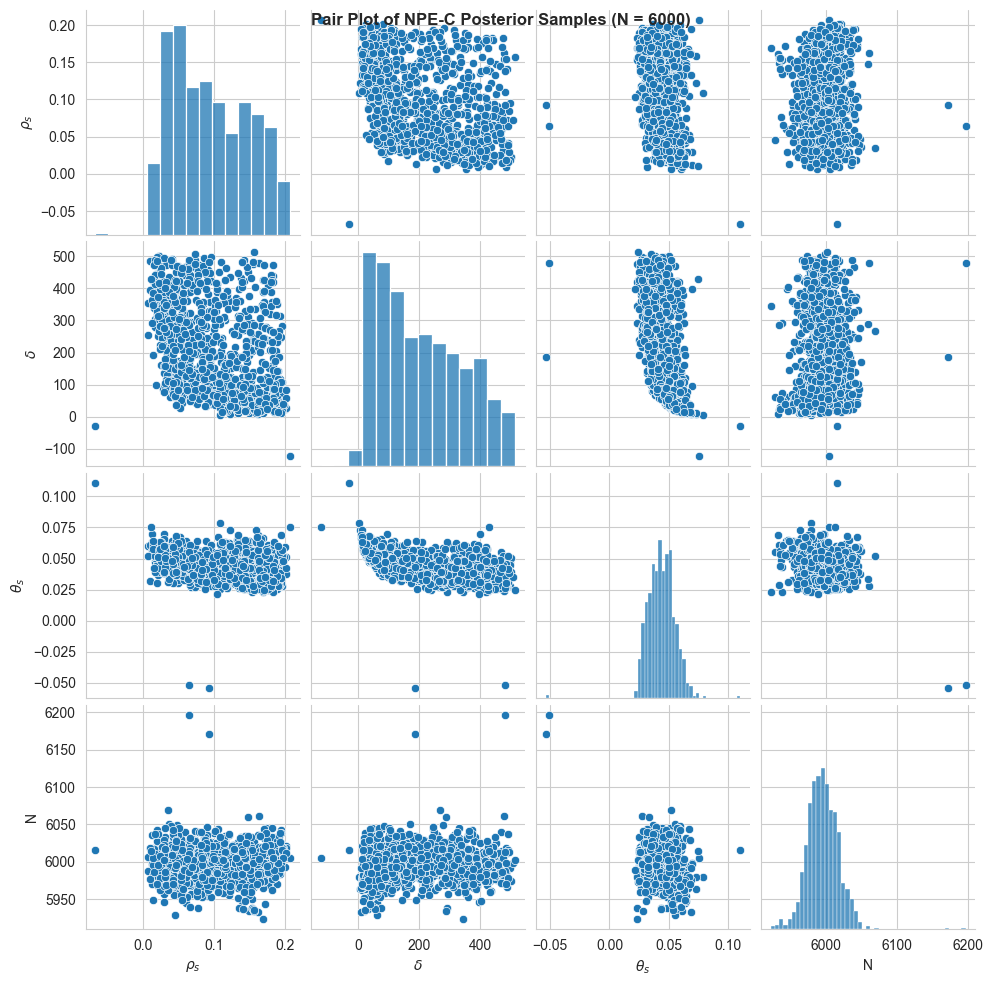

In [57]:
df_6000 = pd.DataFrame(theta_trained_6000_numpy, columns=[r"$\rho_s$", r"$\delta$", r"$\theta_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()